<a href="https://colab.research.google.com/github/tlamadon/abc-of-akm/blob/main/jep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> <a href="https://arxiv.org/abs/2603.17034" target="_blank"><img src="https://img.shields.io/badge/arXiv-2603.17034-b31b1b.svg" alt="arXiv"/></a>

Hello, this is a notebook associated with the JEP article on the ABC of AKM. We provide simple simulation examples to make concrete the different points developed in the paper.

The first part is a quick dive in, while later sections go behind the scenes, explaining how the data is generated and digging deeper into the analysis.

The notebook is fully self-contained and you can look directly at all the code. Some of it is a bit lengthy so the code cell is closed to start with.

We hope this is useful and please provide any feedback directly to us.

In [1]:
#| echo: false
# @title Simulation code (hidden for quick dive)
# we generate a simple homophily network
# that we can later use to simulate data

# !apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.sparse import coo_matrix

import networkx as nx
import pandas as pd

import graphviz
from graphviz import Digraph
from IPython.display import Image
from IPython.display import display, Markdown, HTML

from string import Template
from typing import Any, Dict, List, Tuple, Optional

# plt.rcParams['text.usetex'] = True # TeX rendering
# plt.rcParams['mathtext.fontset'] = 'cm'
# plt.rcParams['font.family'] = 'STIXGeneral'

class Param:
    """Class to hold simulation parameters."""
    def __init__(self, **kwds: Any) -> None:
        self.__dict__.update({
            'rho': 1.0,
            'lambda1': 0.1,
            'sigma': 0.2,
            'ng': 10,
            'nj': 20
        })
        self.__dict__.update(kwds)

    def __str__(self) -> str:
        return ' '.join(f'{key}={value}' for key, value in self.__dict__.items())

    def __repr__(self) -> str:
        return str(self)

def matrix_stationary_distribution(transition_matrix: np.ndarray) -> np.ndarray:
    """Computes the stationary distribution of a Markov transition matrix."""
    eigvals, eigvecs = np.linalg.eig(transition_matrix.T)
    stationary_vec = eigvecs[:, np.isclose(eigvals, 1)]
    stationary_dist = stationary_vec[:, 0].real
    stationary_dist = np.maximum(0, np.sign(stationary_dist.sum()) * stationary_dist)
    stationary_dist /= stationary_dist.sum()
    return stationary_dist

def make_connected(dataset: pd.DataFrame) -> pd.DataFrame:
    """Filters the dataset to retain only the largest connected component of firms."""
    I = dataset['i'].to_numpy()
    J = dataset['j'].to_numpy()
    G = nx.Graph()
    for ii in range(1, len(I)):
        if (I[ii] != I[ii-1]):
            continue
        if (J[ii] != J[ii-1]):
            G.add_edge(J[ii-1], J[ii])
    largest_component = max(nx.connected_components(G), key=len)
    largest_component_list = list(largest_component)
    print("Largest connected component:", len(largest_component_list))
    dfc = dataset[dataset['j'].isin(largest_component_list)].copy()
    dfc.loc[:, 'j'] = pd.factorize(dfc['j'])[0]
    dfc.loc[:, 'i'] = pd.factorize(dfc['i'])[0]
    return dfc

def data_to_matrix(dataset: pd.DataFrame, normalize: bool = False) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Converts the dataset to design matrices for AKM estimation."""
    dataset = dataset.sort_values(by=['i', 't'])
    I = dataset['i'].to_numpy()
    J = dataset['j'].to_numpy()
    nn = len(I)
    nj = len(np.unique(J))
    ni = len(np.unique(I))
    Af = np.zeros((nn, nj-1))
    Aw = np.zeros((nn, ni))
    for n in range(nn):
        if J[n] < nj-1:
            Af[n, J[n]] = 1
        Aw[n, I[n]] = 1
    M = np.hstack((Af, Aw))
    return M, Af, Aw

class Model:
    """Model for simulating worker-firm matching and wages."""
    def __init__(self, p: Optional[Param] = None, **kwds: Any) -> None:
        if p is None:
            p = Param(**kwds)
        else:
            p.__dict__.update(kwds)

        self.lambda1: float = p.lambda1
        self.sigma: float = p.sigma
        self.rho: float = p.rho
        self.psi_j: np.ndarray = norm.ppf(np.linspace(1/p.nj, 1-1/p.nj, p.nj), loc=0, scale=1.0)
        self.alpha_g: np.ndarray = norm.ppf(np.linspace(1/p.ng, 1-1/p.ng, p.ng), loc=0, scale=1.0)
        self.ng: int = p.ng
        self.nj: int = p.nj
        self.H: Optional[np.ndarray] = None

    def tr_pr(self, alpha: float, psi1: float, psi2: float) -> float:
        """Calculates transition probability between psi1 and psi2 for a worker of type alpha."""
        return self.lambda1 * 1 / (1 + np.exp(1/self.rho * ((psi2-alpha)**2 - (psi1-alpha)**2)))

    def construct_transition_matrix(self, alpha: float, psi: np.ndarray) -> np.ndarray:
        """Constructs the full transition matrix for a given worker type."""
        n = len(psi)
        transition_matrix = np.zeros((n, n))
        for j in range(n):
            for jp in range(n):
                transition_matrix[j, jp] = self.tr_pr(alpha, psi[j], psi[jp])
        row_sums = transition_matrix.sum(axis=1, keepdims=True)
        transition_matrix /= row_sums
        return transition_matrix

    def stationary_distribution(self) -> np.ndarray:
        """Computes the stationary distributions for all worker types."""
        H = np.zeros((self.ng, self.nj))
        for g in range(self.ng):
            transition_matrix = self.construct_transition_matrix(self.alpha_g[g], self.psi_j)
            H[g, :] = matrix_stationary_distribution(transition_matrix)
        self.H = H
        return H

    def equilibrium_wages(self) -> np.ndarray:
        """Calculates equilibrium wages for all worker-firm combinations."""
        W = np.zeros((self.ng, self.nj))
        for g in range(self.ng):
            for j in range(self.nj):
                W[g, j] = self.alpha_g[g] + self.psi_j[j]
        return W

    def draw_residuals(self, dataset: pd.DataFrame) -> pd.DataFrame:
        """Draws wage residuals for a dataset."""
        dataset['epsilon'] = np.random.normal(0, 1, len(dataset)) * self.sigma
        dataset['y'] = dataset['alpha'] + dataset['psi'] + dataset['epsilon']
        return dataset

    def simulate(self, ni: int, nt: int, connected: bool = False) -> pd.DataFrame:
        """Simulates a panel dataset of worker-firm matches and wages."""
        if self.H is None:
            self.stationary_distribution()
        data: List[Dict[str, Any]] = []
        for i in range(ni):
            g = np.random.choice(range(self.ng), size=1)[0]
            j = np.random.choice(range(self.nj), size=1, p=self.H[g, :])[0]
            alpha_i = self.alpha_g[g] + np.random.normal(0, 1)
            data.append({'i': i, 'j': j, 't': 0, 'alpha': alpha_i})
            for t in range(1, nt):
                j2 = np.random.choice(range(self.nj), size=1)[0]
                pr_move = self.tr_pr(self.alpha_g[g], self.psi_j[j], self.psi_j[j2])
                if (j != j2) and (np.random.uniform(low=0, high=1) < pr_move):
                    j = j2
                data.append({'i': i, 'j': j, 't': t, 'alpha': alpha_i})
        dataset = pd.DataFrame(data)
        dataset['psi'] = self.psi_j[dataset['j']]
        dataset = self.draw_residuals(dataset)
        if connected:
            dataset = make_connected(dataset)
        return dataset

    def plot_wages_and_distribution(self) -> Tuple[plt.Figure, Any]:
        """Plots the stationary distribution and equilibrium wages."""
        H = self.stationary_distribution()
        W = self.equilibrium_wages()
        palette = sns.mpl_palette("tab10", 10)
        plt.rcParams['axes.prop_cycle'] = plt.cycler(color=palette)
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
        bottom = np.zeros(H.shape[1])
        H2 = H / H.sum(axis=0)
        for i in range(H.shape[0]):
            axes[0].fill_between(self.psi_j, bottom, bottom + H2[i, :])
            bottom += H2[i, :]
        axes[1].plot(self.psi_j, W.transpose())
        return fig, axes

def compute_akm(dataset: pd.DataFrame) -> pd.DataFrame:
    """Computes AKM estimates of worker and firm fixed effects."""
    M, Af, Aw = data_to_matrix(dataset)
    MM = np.matmul(M.transpose(), M)
    x = np.linalg.solve(MM, M.transpose() @ dataset['y'].to_numpy())
    psi_hat = Af @ x[range(Af.shape[1])]
    alpha_hat = Aw @ x[range(Af.shape[1], Aw.shape[1]+Af.shape[1])]
    dataset['alpha_hat'] = alpha_hat
    dataset['psi_hat'] = psi_hat
    return dataset

def variance_decomposition(data: pd.DataFrame, alpha_col: str = "alpha", psi_col: str = "psi", y_col: str = "y", format: str = "dict") -> Dict[str, float]:
    """Decomposes the variance of wages into components."""
    stats = {}
    stats["var_alpha"] = data[alpha_col].var()
    stats["var_psi"] = data[psi_col].var()
    stats["cov_alpha_psi"] = data[alpha_col].cov(data[psi_col])
    eps = data[y_col] - data[alpha_col] - data[psi_col]
    stats["var_eps"] = eps.var()
    return stats

def display_variance_decomposition(stats: Dict[str, float], text: str = "") -> None:
    """Displays the variance decomposition as a markdown table."""
    header = f"**{text}**\n\n" if text else ""
    total = stats['var_alpha'] + stats['var_psi'] + 2*stats['cov_alpha_psi'] + stats['var_eps']
    pct_alpha = 100 * stats['var_alpha'] / total
    pct_psi = 100 * stats['var_psi'] / total
    pct_cov = 100 * 2 * stats['cov_alpha_psi'] / total
    pct_eps = 100 * stats['var_eps'] / total
    md = header + f"""| $Var(\\alpha)$ | $Var(\\psi)$ | $2Cov(\\alpha,\\psi)$ | $Var(\\epsilon)$ |
|:---:|:---:|:---:|:---:|
| {stats['var_alpha']:.2f} | {stats['var_psi']:.2f} | {2*stats['cov_alpha_psi']:.2f} | {stats['var_eps']:.2f} |
| {pct_alpha:.1f}% | {pct_psi:.1f}% | {pct_cov:.1f}% | {pct_eps:.1f}% |"""
    display(Markdown(md))

def abline(slope: float, intercept: float) -> None:
    """Plots a line from slope and intercept."""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--')

## Quick dive, simulate and estimate AKM

We start with a quick dive, brushing over the details. We use the provided functions to create a parameter set and simulate a matched data set.

In [2]:
np.random.seed(6344) # fixing the random seed

# initialize the model from the parameters
model = Model(lambda1=0.15, rho = 2.0 , sigma=1.0, ng=10, nj=100)

# simulate data from the model, impose connectedness
data = model.simulate(1_000, 5, connected=True)

data

Largest connected component: 98


,i,j,t,alpha,psi,epsilon,y
0,0,0,0,1.859599,2.326348,-0.337278,3.848669
1,0,0,1,1.859599,2.326348,1.651831,5.837777
2,0,0,2,1.859599,2.326348,1.341673,5.527619
3,0,1,3,1.859599,-0.161991,0.077705,1.775313
4,0,1,4,1.859599,-0.161991,-0.106895,1.590713
...,...,...,...,...,...,...,...
4995,991,81,0,1.253955,0.504458,-2.644807,-0.886393
4996,991,81,1,1.253955,0.504458,-0.190096,1.568318
4997,991,81,2,1.253955,0.504458,-0.178008,1.580406
4998,991,81,3,1.253955,0.504458,1.291315,3.049729


The data is a panel of workers with the following columns:

- `i`: worker identifier
- `j`: firm identifier
- `t`: time period
- `alpha`: worker wage fixed heterogeneity
- `psi`: firm wage fixed heterogeneity
- `epsilon`: wage residual
- `y`: realized wage

### True variance decomposition

There aren't any estimates at this point. These are the true parameter values and residual realizations. We can compute the "true" variance decomposition.

In [3]:
# let's compute the variance decompostion and display it as a table
var_decomposition_true = variance_decomposition(data)
display_variance_decomposition(var_decomposition_true, text="True model decomposition")

**True model decomposition**

| $Var(\alpha)$ | $Var(\psi)$ | $2Cov(\alpha,\psi)$ | $Var(\epsilon)$ |
|:---:|:---:|:---:|:---:|
| 1.62 | 0.65 | 0.47 | 0.97 |
| 43.6% | 17.6% | 12.6% | 26.2% |

### Compute AKM estimates

We can use the data, the columns `i`, `j` and `y` to compute the AKM estimates of $\psi$ and $\alpha$ and construct a decomposition using these estimates. When calling `compute_akm`, the estimated fixed effects are appended to the data in `alpha_hat` and `psi_hat`.  We can plot the estimated $\psi$ versus the true $\psi$.

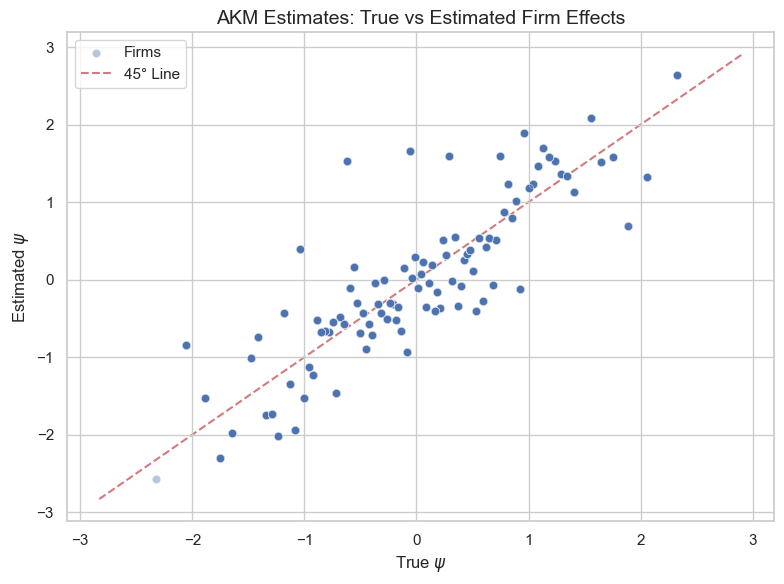

In [4]:
data = compute_akm(data)

# demean estimated firm effects (mean level is not identified)
data['psi_hat'] = data['psi_hat'] - data['psi_hat'].mean()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Main scatter plot
plt.scatter(
    data['psi'],
    data['psi_hat'],
    alpha=0.4,
    edgecolors='w',
    linewidth=0.5,
    label='Firms'
)

# 45-degree reference line
lims = [
    np.min([plt.xlim(), plt.ylim()]),
    np.max([plt.xlim(), plt.ylim()])
]
plt.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='45° Line')

plt.xlabel(r'True $\psi$', fontsize=12)
plt.ylabel(r'Estimated $\psi$', fontsize=12)
plt.title('AKM Estimates: True vs Estimated Firm Effects', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

### Use AKM estimate to construct variance decomposition



In [5]:
var_decomposition_hat = variance_decomposition(data, alpha_col="alpha_hat", psi_col="psi_hat", y_col="y")
display_variance_decomposition(var_decomposition_hat, text="Estimated model decomposition")

**Estimated model decomposition**

| $Var(\alpha)$ | $Var(\psi)$ | $2Cov(\alpha,\psi)$ | $Var(\epsilon)$ |
|:---:|:---:|:---:|:---:|
| 2.13 | 0.88 | -0.06 | 0.75 |
| 57.5% | 23.7% | -1.6% | 20.3% |

As we can see, while we simulated from a model which satisfies all the assumptions of AKM, the realized estimated decomposition is quite off. The variance of the firm effect is much larger and the covariance is much smaller, actually slightly negative.

### Monte-Carlo

We can simulate running the estimator on randomly drawn datasets to learn whether this was only due to the seed we used and this particular draw of the residuals.

We redraw the residuals, recompute the AKM estimates, and compare the average estimate to the true estimate. Because of the properties of OLS we expect this to be very well behaved in expectation.



In [6]:
reps = []
var_psi_reps = []
for rep in range(100):
    psi_hat_rep = compute_akm(model.draw_residuals(data))['psi_hat']
    psi_hat_rep = psi_hat_rep - psi_hat_rep.mean()
    reps.append(psi_hat_rep)
    var_psi_reps.append(psi_hat_rep.var())
psi_hat_mean = np.vstack(reps).mean(axis=0)
psi_hat_sd = np.vstack(reps).std(axis=0)

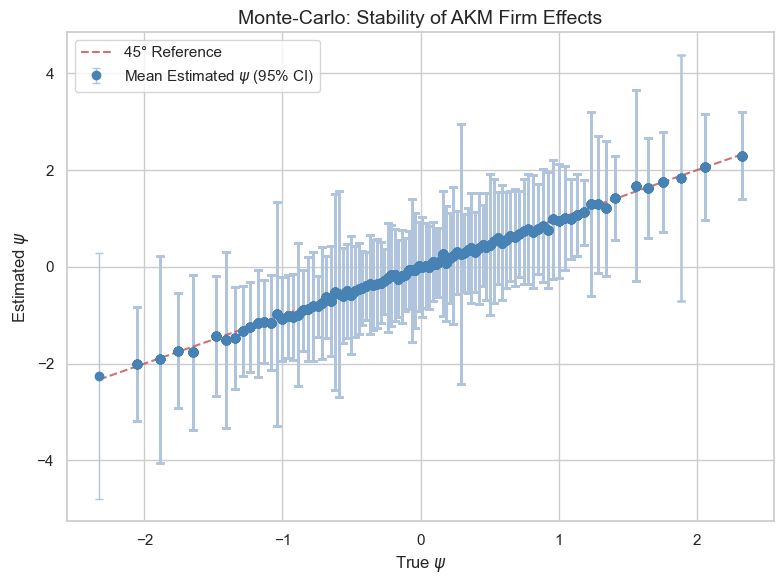

In [7]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Error bar plot
plt.errorbar(data['psi'], psi_hat_mean, yerr=1.96 * psi_hat_sd,
             fmt='o', color='steelblue', ecolor='lightsteelblue',
             capsize=3, elinewidth=1, markeredgewidth=1,
             label=r'Mean Estimated $\psi$ (95% CI)')

# 45-degree reference line
lims = [np.min(data['psi']), np.max(data['psi'])]
plt.plot(lims, lims, 'r--', alpha=0.8, label='45° Reference')

plt.xlabel(r'True $\psi$', fontsize=12)
plt.ylabel(r'Estimated $\psi$', fontsize=12)
plt.title('Monte-Carlo: Stability of AKM Firm Effects', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

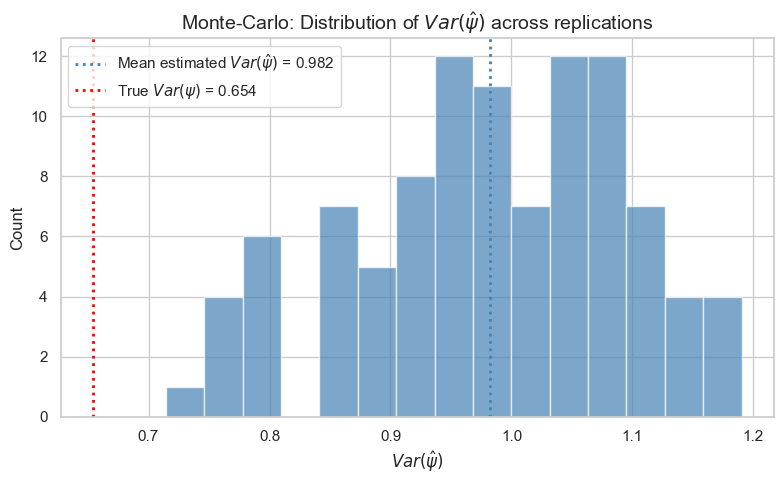

In [8]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

plt.hist(var_psi_reps, bins=15, edgecolor='white', alpha=0.7, color='steelblue')
plt.axvline(np.mean(var_psi_reps), linestyle=':', color='steelblue', linewidth=2,
            label=rf'Mean estimated $Var(\hat\psi)$ = {np.mean(var_psi_reps):.3f}')
plt.axvline(data['psi'].var(), linestyle=':', color='red', linewidth=2,
            label=rf'True $Var(\psi)$ = {data["psi"].var():.3f}')

plt.xlabel(r'$Var(\hat\psi)$', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title(r'Monte-Carlo: Distribution of $Var(\hat\psi)$ across replications', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

We see in the previous graph that the $\psi$ line up very well with the true ones on average. However there is a lot of variation around the estimated values. Such variation contributes to the estimated variance.

# How did we simulate the data?

The data generating process has two ingredients: a **mobility model** that determines how workers move across firms, and a **wage equation** that determines earnings. We describe each in turn, and then illustrate with a small example.

## Mobility with homophily

Workers belong to one of $n_g$ groups indexed by $g$. Each group has a type $\alpha_g$ (drawn from equally spaced quantiles of a standard normal). Firms are indexed by $j$ and have a permanent characteristic $\psi_j$ (also from equally spaced quantiles of a standard normal).

Each period, a worker of group $g$ currently at firm $j$ draws a potential alternative firm $j'$ uniformly at random. The worker moves to $j'$ with probability

$$ P(\text{move to } j' \mid g, j) = \frac{\lambda}{1 + \exp\!\Big(\frac{1}{\rho}\big[(\psi_{j'} - \alpha_g)^2 - (\psi_j - \alpha_g)^2\big]\Big)} $$

The key term is the difference in squared distances $(\psi_{j'} - \alpha_g)^2 - (\psi_j - \alpha_g)^2$. Workers prefer firms whose $\psi_j$ is close to their group type $\alpha_g$ — this is the **homophily** (or sorting) in the model. The parameter $\rho$ controls sensitivity: large $\rho$ means workers care little about match quality and move frequently; small $\rho$ means workers are very selective. The parameter $\lambda$ scales the overall mobility rate.

At $t=0$, each worker's initial firm is drawn from the stationary distribution of the Markov chain implied by this transition rule.

## Wage equation

Wages follow the standard AKM additive structure:

$$ y_{it} = \alpha_i + \psi_{j(i,t)} + \epsilon_{it}, \qquad \epsilon_{it} \sim \mathcal{N}(0, \sigma^2) $$

The individual effect $\alpha_i$ is drawn as $\alpha_i = \alpha_g + u_i$ where $u_i \sim \mathcal{N}(0,1)$, so workers in the same group share a common component but differ idiosyncratically. The firm effect $\psi_{j}$ in the wage equation is the same $\psi_j$ that governs mobility, which ensures that the sorting pattern in mobility directly creates a correlation between $\alpha_i$ and $\psi_j$ in the wage data.

## Summary of parameters

The simulation is controlled by the following parameters:

| Parameter | Code name | Description |
|:---:|:---:|:---|
| $\lambda$ | `lambda1` | Mobility rate — scales the probability of moving to a new firm each period. Higher values produce more job-to-job transitions. |
| $\rho$ | `rho` | Sorting temperature — controls how sensitive mobility is to match quality. Large $\rho$ weakens sorting (workers move nearly at random); small $\rho$ strengthens it (workers only move to better-matched firms). |
| $\sigma$ | `sigma` | Wage noise — standard deviation of the i.i.d. residual $\epsilon_{it}$. Larger values make wages noisier relative to the fixed effects. |
| $n_g$ | `ng` | Number of worker groups — determines the granularity of worker heterogeneity in the mobility process. |
| $n_j$ | `nj` | Number of firms — the total number of distinct employers in the economy. |
| $n_i$ | `ni` | Number of workers — set when calling `simulate()`. |
| $T$ | `nt` | Number of time periods — set when calling `simulate()`. Longer panels generate more transitions and improve AKM precision. |

## A small example

To make this concrete, we simulate a small dataset with $n_j = 5$ firms, $n_i = 10$ workers, and $T = 5$ periods. We select three workers who change employer at least once and plot their wage paths. The lines show the systematic component $\alpha_i + \psi_{j(i,t)}$, which shifts when a worker moves to a firm with a different $\psi_j$. The vertical segments show the residual $\epsilon_{it}$ added on top.

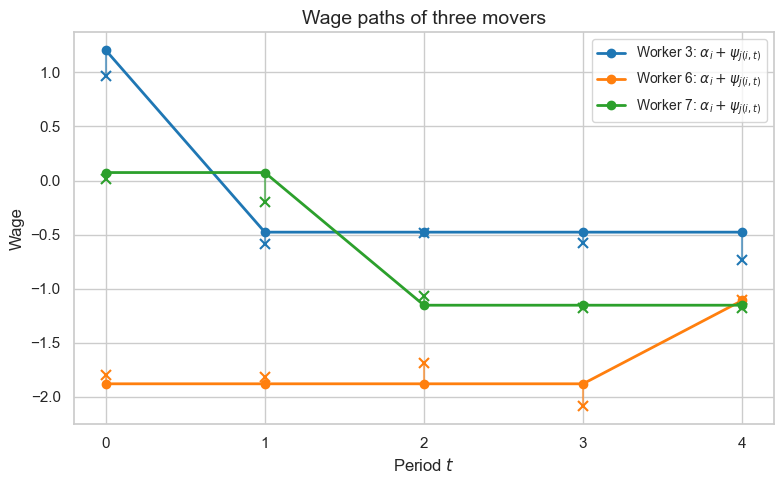

In [9]:
np.random.seed(7236)
p2 = Param(lambda1=0.5, rho=2.0, sigma=0.2, ng=10, nj=5)
model = Model(p2)
dataset = model.simulate(10, 5)

# identify workers who move (work in at least 2 distinct firms)
movers = dataset.groupby('i')['j'].nunique()
mover_ids = movers[movers >= 2].index.tolist()[:3]

sns.set_theme(style="whitegrid")
palette = sns.color_palette("tab10", len(mover_ids))
fig, ax = plt.subplots(figsize=(8, 5))

for idx, worker_id in enumerate(mover_ids):
    wd = dataset[dataset['i'] == worker_id].sort_values('t')
    t = wd['t'].values
    signal = wd['alpha'].values + wd['psi'].values
    y = wd['y'].values
    color = palette[idx]

    # line for alpha + psi
    ax.plot(t, signal, '-o', color=color, linewidth=2, markersize=6,
            label=f'Worker {worker_id}' + r': $\alpha_i + \psi_{{j(i,t)}}$')

    # vertical segments for the residual
    for tt, s, yy in zip(t, signal, y):
        ax.plot([tt, tt], [s, yy], color=color, linewidth=1.5, alpha=0.6)
        ax.plot(tt, yy, 'x', color=color, markersize=7, markeredgewidth=1.5)

ax.set_xlabel('Period $t$', fontsize=12)
ax.set_ylabel('Wage', fontsize=12)
ax.set_xticks(range(5))
ax.set_title('Wage paths of three movers', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Each line traces the systematic component $\alpha_i + \psi_{j(i,t)}$ for one worker. When a worker changes firm, $\psi_j$ changes and the line jumps — these discrete shifts are exactly what AKM exploits for identification. The small vertical segments (ending with an "x") show the residual $\epsilon_{it}$: the gap between the systematic part and the realized wage $y_{it}$.

The raw data (below) shows the same information in tabular form.

Notice that some workers stay at the same firm for the entire panel (e.g., worker 0 at firm 1), while others move (visible as changes in the `j` column across periods for the same worker `i`).

In [10]:
dataset.head(10)

,i,j,t,alpha,psi,epsilon,y
0,0,1,0,1.487477,-0.38532,-0.068936,1.033220
1,0,1,1,1.487477,-0.38532,-0.243309,0.858848
2,0,1,2,1.487477,-0.38532,-0.069345,1.032812
3,0,1,3,1.487477,-0.38532,-0.115942,0.986215
4,0,1,4,1.487477,-0.38532,-0.186344,0.915813
5,1,3,0,1.979183,0.38532,0.125585,2.490089
6,1,3,1,1.979183,0.38532,-0.008635,2.355868
7,1,3,2,1.979183,0.38532,0.081777,2.446280
8,1,3,3,1.979183,0.38532,0.043003,2.407507
9,1,3,4,1.979183,0.38532,-0.298408,2.066095


## From data to design matrix

To estimate AKM, we stack the wage equation across all observations and write it as a linear system $y = X\beta + \epsilon$, where $X$ contains firm and worker indicator columns. The function `data_to_matrix` constructs the firm indicator matrix $A_f$ (with one firm normalized to zero) and the worker indicator matrix $A_w$. Below we show the first five rows of $A_f$: worker 0 is at firm 1 for all five periods, so the second column (firm index 1) contains ones.

In [11]:
M, Af, Aw = data_to_matrix(dataset)
Af[range(5),:]

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

# How did we estimate AKM ?

We construct the matrices associated with the mobility of the workers. We then compute the least square estimates. Finally we compare the predicted $\psi$ to the true $\psi$ values. We do observe some noise.

In [12]:
np.random.seed(6344)
model = Model(lambda1=0.5, rho=2.0, sigma=0.2, ng=10, nj=100)
dataset = model.simulate(1_000, 5, connected=True)

M, Af, Aw = data_to_matrix(dataset)
MM = np.matmul(M.transpose(), M)
x = np.linalg.solve(MM, M.transpose() @ dataset['y'].to_numpy())

psi_jt = dataset['psi'].to_numpy()
alpha_jt = dataset['alpha'].to_numpy()
psi_hat = Af @ x[range(Af.shape[1])]
alpha_hat = Aw @ x[range(Af.shape[1], Aw.shape[1] + Af.shape[1])]

Largest connected component: 100


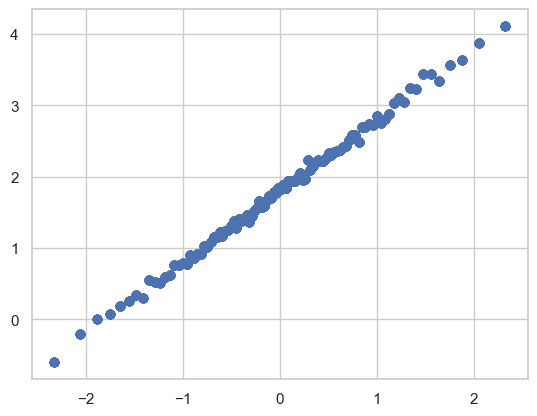

In [13]:
plt.scatter(
    psi_jt,
    psi_hat)
plt.show()